# Experiment 2 — VAE Sample-Size Saturation Study

**Question:** for each QUIDA dataset, how many samples can one trained VAE generate before extra samples
stop adding value (fidelity plateaus and the generator begins repeating itself)?

**Method (no self-consuming loop).** For each dataset and each random seed: train the VAE **once** on the
real training split, then **generate at increasing sizes** (1x, 2x, 3x, 5x, 8x the real count) from that
single fixed model. Every generated set is scored against the same real reference. Results are **averaged
over seeds** so the recommended size is a stable knee, not an artifact of one split.

**Metrics:** MMD, Wasserstein, Correlation Difference, OCSVM coverage gap + Score Gap, Variance Increase,
and Density/Coverage (precision-recall for generative models). Distribution/geometry metrics are computed
in a shared standardized-PCA embedding of the real data; per-channel metrics (Wasserstein, correlation)
in standardized original space.

**Output:** per-dataset metric-vs-size tables and curves (knee marked), PCA overlays across sizes, and a
recommended sample size per dataset, plus a cross-dataset summary.

> Note: a fixed VAE does not lose per-sample quality as you draw more; what saturates is the *marginal
> value* of each extra sample. So the deliverable is a **saturation point**, not a cliff.

## 1. Import libraries

In [31]:
from __future__ import annotations
import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import cdist, pdist
from scipy.stats import wasserstein_distance

import tensorflow as tf
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

_saving = getattr(keras, "saving", None)
def _pick(fn): return getattr(_saving, fn, None) or getattr(keras.utils, fn, None)
register_keras_serializable = _pick("register_keras_serializable") or (lambda **k: (lambda c: c))
serialize_keras_object   = _pick("serialize_keras_object")
deserialize_keras_object = _pick("deserialize_keras_object")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__,
      "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")


TensorFlow: 2.16.1 | Keras: 3.3.3 | GPUs: none (CPU)


## 2. Configuration

In [32]:
@dataclass
class Config:
    data_dir: Path = field(default_factory=lambda: Path.cwd())
    output_dir: Path = field(default_factory=lambda: Path.cwd() / "vae_size_study")
    dataset_glob: str = "*_raw.npy"
    datasets: dict | None = None

    seed: int = 42
    val_split: float = 0.2

    # --- sample-size sweep ---
    multipliers: tuple = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10)   # N = multiplier * n_real
    n_seeds: int = 3                        # raise to 5 for a more stable knee (slower)
    recommend_tol: float = 0.05            # stop when remaining composite gain < this

    # --- preprocessing (reversible) ---
    use_signed_log: bool = True
    drop_constant: bool = True
    const_eps: float = 1e-8
    use_pca: bool = True
    pca_components: int = 32

    # --- model ---
    latent_dim: int = 16
    beta: float = 1.0
    free_bits: float = 0.5
    kl_anneal_epochs: int = 30
    base_filters: int = 64

    # --- training ---
    epochs: int = 250
    batch_size: int = 32
    learning_rate: float = 1e-3
    early_stopping_patience: int = 30

    sample_from_posterior: bool = True

    # --- evaluation ---
    emb_max_dim: int = 30
    ocsvm_nu: float = 0.1
    dc_k: int = 5
    feat_cap: int = 150         # subsample this many channels for Wasserstein/correlation on wide sets
    mmd_cap: int = 800
    pca_plot: bool = True
    kl_collapse_thresh: float = 1e-2

CFG = Config()
CFG.output_dir.mkdir(parents=True, exist_ok=True)
print("Output:", CFG.output_dir, "| multipliers:", CFG.multipliers, "| seeds:", CFG.n_seeds)


Output: c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_size_study | multipliers: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10) | seeds: 3


In [33]:
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed); random.seed(seed); np.random.seed(seed)
    try: keras.utils.set_random_seed(seed)
    except Exception: tf.random.set_seed(seed)
set_seeds(CFG.seed)


## 3. Load the four datasets

In [34]:
def _clean_name(fn):
    s = Path(fn).stem; return s[:-4] if s.endswith("_raw") else s

def discover_datasets(cfg):
    if cfg.datasets:
        items = list(cfg.datasets.items())
        miss = [str(cfg.data_dir/f) for _,f in items if not (cfg.data_dir/f).exists()]
        if miss: raise FileNotFoundError("Missing: " + ", ".join(miss))
    else:
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob), key=lambda q:(q.name.count("_"), q.name))
        if not files: raise FileNotFoundError(f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]
    data={}
    for name,fname in items:
        data[name]=np.load(cfg.data_dir/fname, allow_pickle=False).astype(np.float32)
        print(f"  {name:16s} <- {fname:26s} {data[name].shape}")
    return data
RAW = discover_datasets(CFG)


  X_imu            <- X_imu_raw.npy              (99, 32, 3)
  X_imu_ir         <- X_imu_ir_raw.npy           (99, 32, 771)
  X_imu_radar      <- X_imu_radar_raw.npy        (99, 32, 1137)
  X_imu_ir_radar   <- X_imu_ir_radar_raw.npy     (99, 32, 1905)


## 4. Data validation

In [35]:
def validate_dataset(name, X, cfg):
    assert X.ndim==3, f"{name}: need (N,T,F), got {X.shape}"
    N,T,F=X.shape
    n_nan,n_inf=int(np.isnan(X).sum()),int(np.isinf(X).sum())
    if n_nan or n_inf:
        X=np.where(np.isfinite(X),X,np.nan)
        fm=np.nan_to_num(np.nanmean(X.reshape(-1,F),axis=0)); ii=np.where(~np.isfinite(X)); X[ii]=np.take(fm,ii[2])
        print(f"  ! {name}: imputed {n_nan} NaN / {n_inf} Inf")
    nconst=int((np.ptp(X.reshape(-1,F).astype(np.float64),axis=0)<=cfg.const_eps).sum())
    print(f"  {name:16s} N={N} T={T} F={F} const_cols={nconst} min={X.min():+.1f} max={X.max():+.1f}")
    return X.astype(np.float32)
RAW={n:validate_dataset(n,X,CFG) for n,X in RAW.items()}


  X_imu            N=99 T=32 F=3 const_cols=0 min=-73.4 max=+72.1
  X_imu_ir         N=99 T=32 F=771 const_cols=0 min=-73.4 max=+72.1
  X_imu_radar      N=99 T=32 F=1137 const_cols=294 min=-73.4 max=+1523.0
  X_imu_ir_radar   N=99 T=32 F=1905 const_cols=294 min=-73.4 max=+1523.0


## 5. Reversible preprocessing (`Prep`)

In [36]:
def _slog(x): return np.sign(x)*np.log1p(np.abs(x))
def _islog(y): return np.sign(y)*np.expm1(np.abs(y))

class Prep:
    def __init__(self,cfg): self.cfg=cfg
    def fit(self,X):
        N,T,F=X.shape; self.T,self.F_full=T,F
        o=X.reshape(-1,F).astype(np.float64)
        self.keep=(np.ptp(o,axis=0)>self.cfg.const_eps) if self.cfg.drop_constant else np.ones(F,bool)
        lg=_slog(o) if self.cfg.use_signed_log else o
        self.const=lg.mean(0); kept=lg[:,self.keep]
        if self.cfg.use_pca and kept.shape[1]>self.cfg.pca_components:
            k=min(self.cfg.pca_components,kept.shape[1],len(kept)-1)
            self.pca=PCA(k,random_state=self.cfg.seed).fit(kept); comps=self.pca.transform(kept)
        else: self.pca=None; comps=kept
        self.scaler=MinMaxScaler().fit(comps); self.K=comps.shape[1]; self.n_dropped=int((~self.keep).sum())
        return self
    def transform(self,X):
        n=len(X); lg=X.reshape(-1,self.F_full).astype(np.float64)
        if self.cfg.use_signed_log: lg=_slog(lg)
        kept=lg[:,self.keep]; comps=self.pca.transform(kept) if self.pca is not None else kept
        return self.scaler.transform(comps).reshape(n,self.T,self.K).astype("float32")
    def inverse(self,Xs):
        n=len(Xs); comps=self.scaler.inverse_transform(Xs.reshape(-1,self.K))
        kept=self.pca.inverse_transform(comps) if self.pca is not None else comps
        full=np.zeros((len(kept),self.F_full)); full[:,self.keep]=kept
        if self.n_dropped: full[:,~self.keep]=self.const[~self.keep]
        if self.cfg.use_signed_log: full=_islog(full)
        return full.reshape(n,self.T,self.F_full).astype("float32")

def split_data(X,cfg,seed):
    return train_test_split(X,test_size=cfg.val_split,random_state=seed,shuffle=True)


## 6. Build the Beta-VAE (free-bits + annealable beta)

In [37]:
@register_keras_serializable()
class Sampling(layers.Layer):
    def call(self,inp):
        zm,zlv=inp; return zm+tf.exp(0.5*zlv)*tf.random.normal(tf.shape(zm))

def build_encoder(T,F,ld,base):
    xi=keras.Input((T,F))
    x=layers.Conv1D(base,3,padding="same",activation="relu")(xi)
    x=layers.Conv1D(base,3,padding="same",activation="relu")(x)
    x=layers.Conv1D(base//2,3,padding="same",activation="relu")(x)
    x=layers.Flatten()(x); x=layers.Dense(base,activation="relu")(x)
    zm=layers.Dense(ld,name="z_mean")(x); zlv=layers.Dense(ld,name="z_log_var")(x)
    return keras.Model(xi,[zm,zlv,Sampling()([zm,zlv])],name="encoder")

def build_decoder(T,F,ld,base):
    zi=keras.Input((ld,))
    x=layers.Dense(base,activation="relu")(zi); x=layers.Dense(T*(base//2),activation="relu")(x)
    x=layers.Reshape((T,base//2))(x)
    x=layers.Conv1D(base,3,padding="same",activation="relu")(x)
    x=layers.Conv1D(base,3,padding="same",activation="relu")(x)
    return keras.Model(zi,layers.Conv1D(F,3,padding="same",activation="sigmoid")(x),name="decoder")

@register_keras_serializable()
class BetaVAE(keras.Model):
    def __init__(self,encoder,decoder,beta=1.0,free_bits=0.0,**kw):
        super().__init__(**kw); self.encoder,self.decoder=encoder,decoder
        self.beta_target=float(beta); self.free_bits=float(free_bits)
        self.beta_var=tf.Variable(float(beta),trainable=False,dtype=tf.float32,name="beta")
        self.total_tracker=keras.metrics.Mean(name="total_loss")
        self.rec_tracker=keras.metrics.Mean(name="reconstruction_loss")
        self.kl_tracker=keras.metrics.Mean(name="kl_loss")
    @property
    def metrics(self): return [self.total_tracker,self.rec_tracker,self.kl_tracker]
    def compute_losses(self,x):
        zm,zlv,z=self.encoder(x); recon=self.decoder(z)
        rec=tf.reduce_mean(tf.reduce_sum(tf.square(x-recon),axis=[1,2]))
        kld=-0.5*(1+zlv-tf.square(zm)-tf.exp(zlv)); kldm=tf.reduce_mean(kld,axis=0)
        kl_raw=tf.reduce_sum(kldm); kl_fb=tf.reduce_sum(tf.maximum(kldm,self.free_bits))
        return rec,kl_raw,rec+self.beta_var*kl_fb
    def train_step(self,data):
        x=data[0] if isinstance(data,(tuple,list)) else data
        with tf.GradientTape() as tape: rec,kl,tot=self.compute_losses(x)
        self.optimizer.apply_gradients(zip(tape.gradient(tot,self.trainable_weights),self.trainable_weights))
        self.total_tracker.update_state(tot); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {"loss":self.total_tracker.result(),"reconstruction_loss":self.rec_tracker.result(),"kl_loss":self.kl_tracker.result()}
    def call(self,x,training=None):
        _,_,z=self.encoder(x); return self.decoder(z)
    def get_config(self):
        return {"encoder":serialize_keras_object(self.encoder),"decoder":serialize_keras_object(self.decoder),
                "beta":self.beta_target,"free_bits":self.free_bits}
    @classmethod
    def from_config(cls,c):
        return cls(deserialize_keras_object(c["encoder"]),deserialize_keras_object(c["decoder"]),
                   beta=c["beta"],free_bits=c.get("free_bits",0.0))

def build_vae(T,F,cfg):
    v=BetaVAE(build_encoder(T,F,cfg.latent_dim,cfg.base_filters),
              build_decoder(T,F,cfg.latent_dim,cfg.base_filters),beta=cfg.beta,free_bits=cfg.free_bits)
    v.compile(optimizer=keras.optimizers.Adam(cfg.learning_rate)); return v


## 7. Train the VAE (once per seed)

In [38]:
class KLAnneal(keras.callbacks.Callback):
    def __init__(self,bv,t,n): super().__init__(); self.bv,self.t,self.n=bv,float(t),max(1,int(n))
    def on_epoch_begin(self,epoch,logs=None): self.bv.assign(self.t*min(1.0,(epoch+1)/self.n))

class ValLoss(keras.callbacks.Callback):
    def __init__(self,Xv,fb): super().__init__(); self.Xv=Xv.astype("float32"); self.fb=float(fb)
    def on_epoch_end(self,epoch,logs=None):
        if logs is None: return
        zm,zlv,z=self.model.encoder(self.Xv,training=False); recon=self.model.decoder(z,training=False)
        vrec=float(tf.reduce_mean(tf.reduce_sum(tf.square(self.Xv-recon),axis=[1,2])))
        kldm=tf.reduce_mean(-0.5*(1+zlv-tf.square(zm)-tf.exp(zlv)),axis=0)
        vkl=float(tf.reduce_sum(kldm)); vkl_fb=float(tf.reduce_sum(tf.maximum(kldm,self.fb)))
        logs["val_reconstruction_loss"]=vrec; logs["val_kl_loss"]=vkl
        logs["val_loss"]=vrec+float(self.model.beta_var.numpy())*vkl_fb

def train_vae(vae,Xtr,Xval,cfg):
    mon="val_reconstruction_loss"
    cbs=[KLAnneal(vae.beta_var,cfg.beta,cfg.kl_anneal_epochs), ValLoss(Xval,cfg.free_bits),
         keras.callbacks.EarlyStopping(monitor=mon,mode="min",patience=cfg.early_stopping_patience,restore_best_weights=True),
         keras.callbacks.ReduceLROnPlateau(monitor=mon,mode="min",factor=0.5,patience=12,min_lr=1e-5)]
    hist=vae.fit(Xtr,epochs=cfg.epochs,batch_size=cfg.batch_size,shuffle=True,verbose=0,callbacks=cbs)
    return hist

def fit_latent_prior(vae,Xtr):
    zm,_,_=vae.encoder.predict(Xtr,batch_size=128,verbose=0)
    return zm.mean(0).astype("float32"),(zm.std(0)+1e-6).astype("float32")

def generate(vae,prep,n,cfg,latent):
    if cfg.sample_from_posterior and latent is not None:
        mu,sd=latent; z=(np.random.normal(size=(n,cfg.latent_dim))*sd+mu).astype("float32")
    else: z=np.random.normal(size=(n,cfg.latent_dim)).astype("float32")
    return prep.inverse(vae.decoder.predict(z,batch_size=256,verbose=0)).astype("float32")


## 8. Evaluation metrics

Distribution/geometry metrics use a shared standardized-PCA embedding of the **real** data (fit once per
dataset, so all sizes are comparable). Per-channel metrics use standardized original features.

In [39]:
def make_embedding(real,cfg):
    R=real.reshape(len(real),-1).astype(np.float64)
    sc=StandardScaler().fit(R); Rs=sc.transform(R)
    k=min(cfg.emb_max_dim,Rs.shape[1],max(2,len(Rs)-1))
    pca=PCA(k,random_state=cfg.seed).fit(Rs) if Rs.shape[1]>k else None
    def emb(X):
        Xs=sc.transform(X.reshape(len(X),-1).astype(np.float64))
        return pca.transform(Xs) if pca is not None else Xs
    return emb

def mmd_rbf(Re,Se,rng,cap):
    X=Re[rng.choice(len(Re),min(cap,len(Re)),replace=False)]
    Y=Se[rng.choice(len(Se),min(cap,len(Se)),replace=False)]
    med=np.median(cdist(X[:200],X[:200])); med=med if med>0 else 1.0
    return float(np.mean([rbf_kernel(X,X,g/med**2).mean()+rbf_kernel(Y,Y,g/med**2).mean()
                          -2*rbf_kernel(X,Y,g/med**2).mean() for g in (0.5,1,2)]))

def ocsvm_metrics(Re,Se,nu):
    oc=OneClassSVM(nu=nu,gamma="scale").fit(Re)
    ri=float((oc.predict(Re)==1).mean()); si=float((oc.predict(Se)==1).mean())
    return abs(ri-si), abs(float(oc.decision_function(Re).mean())-float(oc.decision_function(Se).mean()))

def density_coverage(Re,Se,k):
    k=min(k,len(Re)-1); nn=NearestNeighbors(n_neighbors=k+1).fit(Re)
    radii=nn.kneighbors(Re)[0][:,k]; inside=cdist(Se,Re)<=radii[None,:]
    return float(inside.sum()/(k*len(Se))), float(inside.any(axis=0).mean())

def variance_increase(Re,Se):
    tr=float(Re.var(0).sum()); ta=float(np.vstack([Re,Se]).var(0).sum())
    return float(ta/tr-1.0) if tr>0 else 0.0

def wasserstein_feat(real,synth,rng,cap):
    F=real.shape[-1]; idx=rng.choice(F,min(cap,F),replace=False)
    m=real.reshape(-1,F).mean(0); s=real.reshape(-1,F).std(0); s=np.where(s>1e-8,s,1.0)
    return float(np.mean([wasserstein_distance((real[...,f].ravel()-m[f])/s[f],
                                               (synth[...,f].ravel()-m[f])/s[f]) for f in idx]))

def corr_difference(real,synth,rng,cap):
    F=real.shape[-1]; idx=np.sort(rng.choice(F,min(cap,F),replace=False))
    with np.errstate(invalid="ignore",divide="ignore"):
        Cr=np.corrcoef(real.reshape(-1,F)[:,idx].T); Cs=np.corrcoef(synth.reshape(-1,F)[:,idx].T)
    return float(np.linalg.norm(np.nan_to_num(Cr)-np.nan_to_num(Cs))/len(idx))

def eval_all(real,synth,Re,Se,cfg,rng):
    cg,sg=ocsvm_metrics(Re,Se,cfg.ocsvm_nu); d,c=density_coverage(Re,Se,cfg.dc_k)
    return {"mmd":mmd_rbf(Re,Se,rng,cfg.mmd_cap),"wasserstein":wasserstein_feat(real,synth,rng,cfg.feat_cap),
            "corr_difference":corr_difference(real,synth,rng,cfg.feat_cap),"coverage_gap":cg,"score_gap":sg,
            "variance_increase":variance_increase(Re,Se),"density":d,"coverage":c}


## 9. Run the sample-size sweep

For each dataset x seed: train once, then generate & evaluate at every size. Seed-0 models are kept for
the visualisations.

In [40]:
def run_sweep(cfg):
    records=[]; embeds={}; keep_model={}
    for name,X in RAW.items():
        print(f"\n=== {name} ({X.shape}) ===")
        emb=make_embedding(X,cfg); Re=emb(X); embeds[name]={"Re":Re,"synth":{}}
        n_real=len(X); rng=np.random.default_rng(cfg.seed)
        for si in range(cfg.n_seeds):
            seed=cfg.seed+si; set_seeds(seed)
            Xtr,Xval=split_data(X,cfg,seed); prep=Prep(cfg).fit(Xtr)
            Xtr_s,Xval_s=prep.transform(Xtr),prep.transform(Xval)
            t0=time.time(); vae=build_vae(prep.T,prep.K,cfg); hist=train_vae(vae,Xtr_s,Xval_s,cfg)
            latent=fit_latent_prior(vae,Xtr_s)
            print(f"  seed {seed}: trained {len(hist.history['loss'])} ep in {time.time()-t0:.0f}s "
                  f"(K={prep.K}, dropped {prep.n_dropped})")
            for m in cfg.multipliers:
                N=int(m*n_real); synth=generate(vae,prep,N,cfg,latent); Se=emb(synth)
                r=eval_all(X,synth,Re,Se,cfg,rng)
                records.append({"dataset":name,"multiplier":m,"N":N,"seed":seed,**r})
                if si==0: embeds[name]["synth"][N]=Se
            if si==0: keep_model[name]=(vae,prep,latent,hist.history)
    return pd.DataFrame(records), embeds, keep_model

RESULTS, EMB, MODELS = run_sweep(CFG)
RESULTS.to_csv(CFG.output_dir/"sweep_raw.csv",index=False)
print("\nsweep done. rows:",len(RESULTS))



=== X_imu ((99, 32, 3)) ===
  seed 42: trained 229 ep in 12s (K=3, dropped 0)
  seed 43: trained 250 ep in 13s (K=3, dropped 0)
  seed 44: trained 227 ep in 12s (K=3, dropped 0)

=== X_imu_ir ((99, 32, 771)) ===
  seed 42: trained 218 ep in 12s (K=32, dropped 0)
  seed 43: trained 227 ep in 12s (K=32, dropped 0)
  seed 44: trained 250 ep in 13s (K=32, dropped 0)

=== X_imu_radar ((99, 32, 1137)) ===
  seed 42: trained 129 ep in 8s (K=32, dropped 294)
  seed 43: trained 57 ep in 5s (K=32, dropped 294)
  seed 44: trained 194 ep in 11s (K=32, dropped 294)

=== X_imu_ir_radar ((99, 32, 1905)) ===
  seed 42: trained 129 ep in 8s (K=32, dropped 294)
  seed 43: trained 57 ep in 5s (K=32, dropped 294)
  seed 44: trained 159 ep in 10s (K=32, dropped 294)

sweep done. rows: 120


## 10. Aggregate + recommend the saturation size

Metrics are averaged over seeds. A composite score (mean of min-max-normalised, higher-is-better
components: -MMD, -Wasserstein, -Correlation, -coverage_gap, -score_gap, +coverage, +density) captures
both fidelity and diversity. The recommended size is the **smallest** N whose remaining composite gain to
the maximum is below `recommend_tol`.

In [41]:
MET_DIR = {"mmd":0,"wasserstein":0,"corr_difference":0,"coverage_gap":0,"score_gap":0,
           "variance_increase":1,"density":1,"coverage":1}   # 1 = higher better

def aggregate(results):
    g=results.groupby(["dataset","multiplier","N"])
    return g.mean(numeric_only=True).reset_index().drop(columns="seed"), g.std(numeric_only=True).reset_index().drop(columns="seed")

def _norm(x,hi):
    x=np.asarray(x,float); lo,h=np.nanmin(x),np.nanmax(x)
    if h-lo<1e-12: return np.ones_like(x)
    z=(x-lo)/(h-lo); return z if hi else 1-z

def recommend(sub,cfg):
    sub=sub.sort_values("N")
    comps=[_norm(sub[c].values,MET_DIR[c]) for c in ["mmd","wasserstein","corr_difference","coverage_gap","score_gap","coverage","density"]]
    C=np.mean(comps,axis=0); Cmax=C.max(); sizes=sub["N"].values; ri=len(sizes)-1
    for i in range(len(sizes)):
        if Cmax-C[i]<cfg.recommend_tol: ri=i; break
    return C, int(sizes[ri]), int(sub["multiplier"].values[ri])

AGG, AGG_STD = aggregate(RESULTS)
REC={}
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N").reset_index(drop=True)
    C,recN,recM=recommend(sub,CFG); sub=sub.copy(); sub["composite"]=C
    AGG.loc[AGG.dataset==name,"composite"]=C
    REC[name]=dict(N=recN,multiplier=recM,composite_at_rec=float(sub.loc[sub.N==recN,"composite"].iloc[0]))
    print(f"{name:16s} -> recommend N={recN} ({recM}x)  composite={REC[name]['composite_at_rec']:.3f}")


X_imu            -> recommend N=297 (3x)  composite=0.726
X_imu_ir         -> recommend N=297 (3x)  composite=0.834
X_imu_radar      -> recommend N=297 (3x)  composite=0.771
X_imu_ir_radar   -> recommend N=693 (7x)  composite=0.752


## 11. Comparison tables

In [42]:
SHOW=["multiplier","N","mmd","wasserstein","corr_difference","coverage_gap","score_gap",
      "variance_increase","density","coverage","composite"]
for name in RAW:
    sub=AGG[AGG.dataset==name].sort_values("N")[SHOW].reset_index(drop=True)
    sub.insert(0,"pick",np.where(sub.N==REC[name]["N"],"<== recommend",""))
    print(f"\n########## {name}  (recommended N={REC[name]['N']}, {REC[name]['multiplier']}x) ##########")
    display(sub.set_index("multiplier"))
    sub.to_csv(CFG.output_dir/f"{name}_table.csv",index=False)

cross=pd.DataFrame([{"dataset":n,"n_features":RAW[n].shape[-1],"recommend_N":REC[n]["N"],
                     "multiplier":f"{REC[n]['multiplier']}x",
                     **{k:float(AGG[(AGG.dataset==n)&(AGG.N==REC[n]['N'])][k].iloc[0])
                        for k in ["mmd","wasserstein","corr_difference","score_gap","variance_increase","coverage"]}}
                    for n in RAW]).set_index("dataset")
print("\n################ CROSS-DATASET RECOMMENDATION ################")
display(cross); cross.to_csv(CFG.output_dir/"cross_dataset_summary.csv")



########## X_imu  (recommended N=297, 3x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.2751,0.4021,0.3243,0.1246,0.1776,-0.2762,1.4135,0.5960,0.5089
2,,198,0.2635,0.4055,0.3296,0.1515,0.1581,-0.3841,1.2949,0.6397,0.2984
3,<== recommend,297,0.2456,0.3993,0.3223,0.1560,0.1637,-0.4379,1.3793,0.7104,0.7260
4,,396,0.2612,0.4061,0.3310,0.1423,0.1843,-0.5173,1.3749,0.7475,0.3679
5,,495,0.2678,0.4074,0.3255,0.1098,0.1945,-0.5661,1.3992,0.8148,0.5372
6,,594,0.2592,0.4026,0.3233,0.1369,0.1787,-0.5626,1.3435,0.7138,0.5441
7,,693,0.2613,0.4051,0.3271,0.1409,0.1759,-0.5792,1.3667,0.7374,0.4706
8,,792,0.2620,0.4063,0.3273,0.1460,0.1638,-0.5824,1.3417,0.7946,0.4814
9,,891,0.2611,0.4048,0.3247,0.1291,0.1770,-0.6050,1.3927,0.7879,0.6126



########## X_imu_ir  (recommended N=297, 3x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.1930,0.5209,0.3429,0.1717,0.6523,-0.4531,2.8727,0.5859,0.3436
2,,198,0.1973,0.5186,0.3249,0.1717,0.6480,-0.6124,2.8017,0.5960,0.3705
3,<== recommend,297,0.1903,0.5000,0.3276,0.1717,0.6478,-0.6847,2.9295,0.6364,0.8342
4,,396,0.1935,0.5134,0.3492,0.1717,0.6488,-0.7345,2.8673,0.6263,0.4536
5,,495,0.1958,0.5140,0.3453,0.1717,0.6431,-0.7690,2.8921,0.6397,0.5428
6,,594,0.1910,0.5108,0.3250,0.1717,0.6480,-0.7857,2.9189,0.6633,0.7925
7,,693,0.1930,0.5079,0.3267,0.1717,0.6432,-0.8046,2.9219,0.6599,0.8165
8,,792,0.1954,0.5138,0.3417,0.1717,0.6463,-0.8212,2.8732,0.6532,0.5388
9,,891,0.1940,0.5145,0.3309,0.1717,0.6449,-0.8303,2.9099,0.6599,0.6922



########## X_imu_radar  (recommended N=297, 3x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.3037,0.2687,0.3555,0.1717,0.2829,-0.4466,2.0444,0.5892,0.3834
2,,198,0.3021,0.2720,0.3516,0.1717,0.2830,-0.6111,2.1609,0.6195,0.6388
3,<== recommend,297,0.3012,0.2724,0.3392,0.1717,0.2826,-0.6958,2.1549,0.6296,0.7712
4,,396,0.3064,0.2924,0.3439,0.1717,0.2811,-0.7491,2.0389,0.6195,0.4582
5,,495,0.3037,0.2864,0.3661,0.1717,0.2829,-0.7849,2.1057,0.6263,0.4219
6,,594,0.3029,0.2793,0.3669,0.1717,0.2807,-0.8099,2.1366,0.6263,0.6407
7,,693,0.3018,0.2735,0.3493,0.1717,0.2826,-0.8281,2.1382,0.6465,0.7229
8,,792,0.3038,0.2559,0.3574,0.1717,0.2812,-0.8444,2.1035,0.6364,0.7133
9,,891,0.3018,0.2580,0.3610,0.1717,0.2812,-0.8560,2.1470,0.6364,0.7918



########## X_imu_ir_radar  (recommended N=693, 7x) ##########


,pick,N,mmd,wasserstein,corr_difference,coverage_gap,score_gap,variance_increase,density,coverage,composite
multiplier,,,,,,,,,,,
1,,99,0.2685,0.4372,0.4018,0.1818,0.5112,-0.4770,2.1542,0.2391,0.4056
2,,198,0.2674,0.4388,0.3868,0.1818,0.5098,-0.6429,2.1357,0.2593,0.6910
3,,297,0.2671,0.4374,0.4008,0.1818,0.5107,-0.7282,2.1428,0.2593,0.6154
4,,396,0.2682,0.4430,0.3908,0.1818,0.5113,-0.7795,2.1471,0.2593,0.4834
5,,495,0.2680,0.4349,0.4174,0.1818,0.5113,-0.8141,2.1305,0.2593,0.3285
6,,594,0.2678,0.4326,0.3965,0.1818,0.5106,-0.8387,2.1348,0.2727,0.6225
7,<== recommend,693,0.2674,0.4240,0.3940,0.1818,0.5111,-0.8571,2.1472,0.2727,0.7518
8,,792,0.2681,0.4329,0.4091,0.1818,0.5112,-0.8720,2.1441,0.2660,0.4968
9,,891,0.2675,0.4214,0.3963,0.1818,0.5103,-0.8833,2.1422,0.2660,0.7627



################ CROSS-DATASET RECOMMENDATION ################


,n_features,recommend_N,multiplier,mmd,wasserstein,corr_difference,score_gap,variance_increase,coverage
dataset,,,,,,,,,
X_imu,3,297,3x,0.2456,0.3993,0.3223,0.1637,-0.4379,0.7104
X_imu_ir,771,297,3x,0.1903,0.5000,0.3276,0.6478,-0.6847,0.6364
X_imu_radar,1137,297,3x,0.3012,0.2724,0.3392,0.2826,-0.6958,0.6296
X_imu_ir_radar,1905,693,7x,0.2674,0.4240,0.3940,0.5111,-0.8571,0.2727


## 12. Visualizations

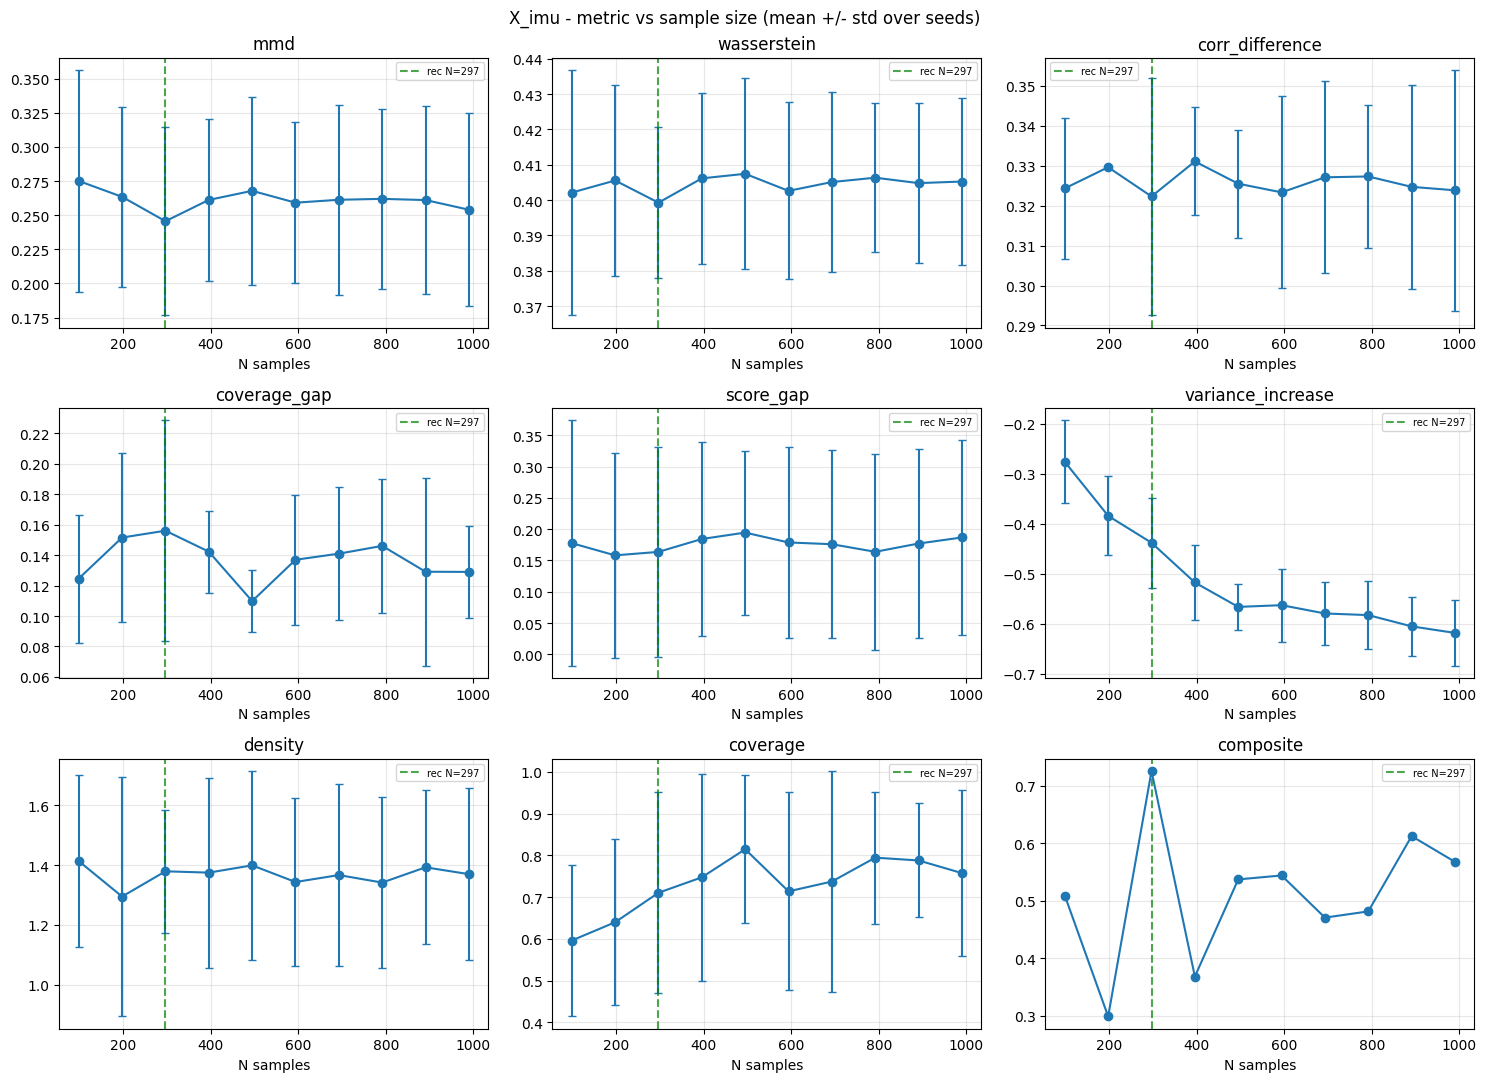

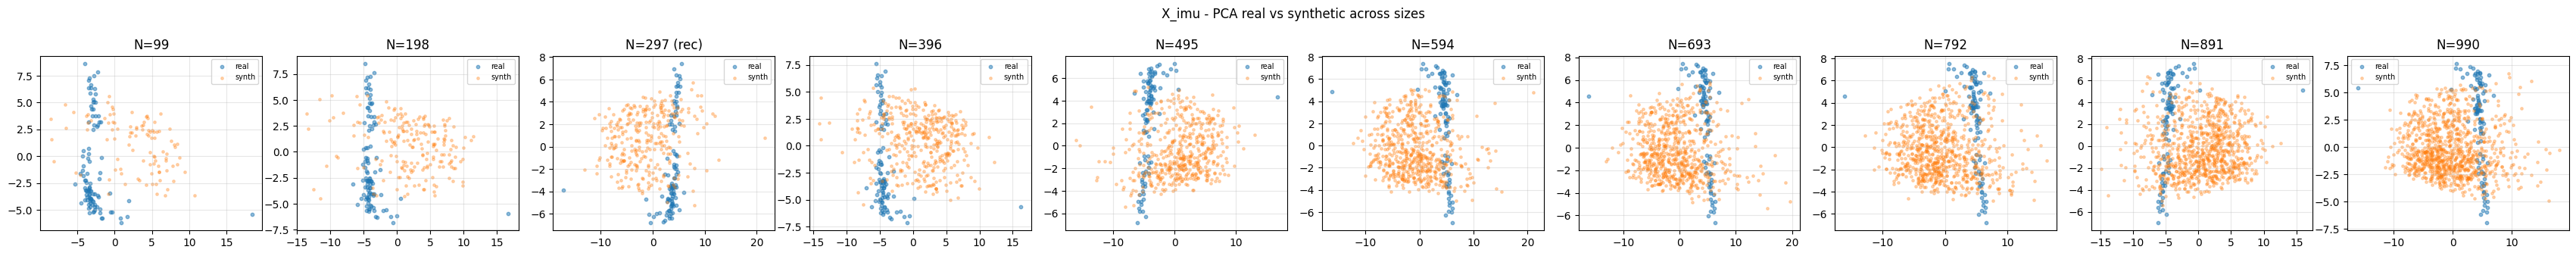

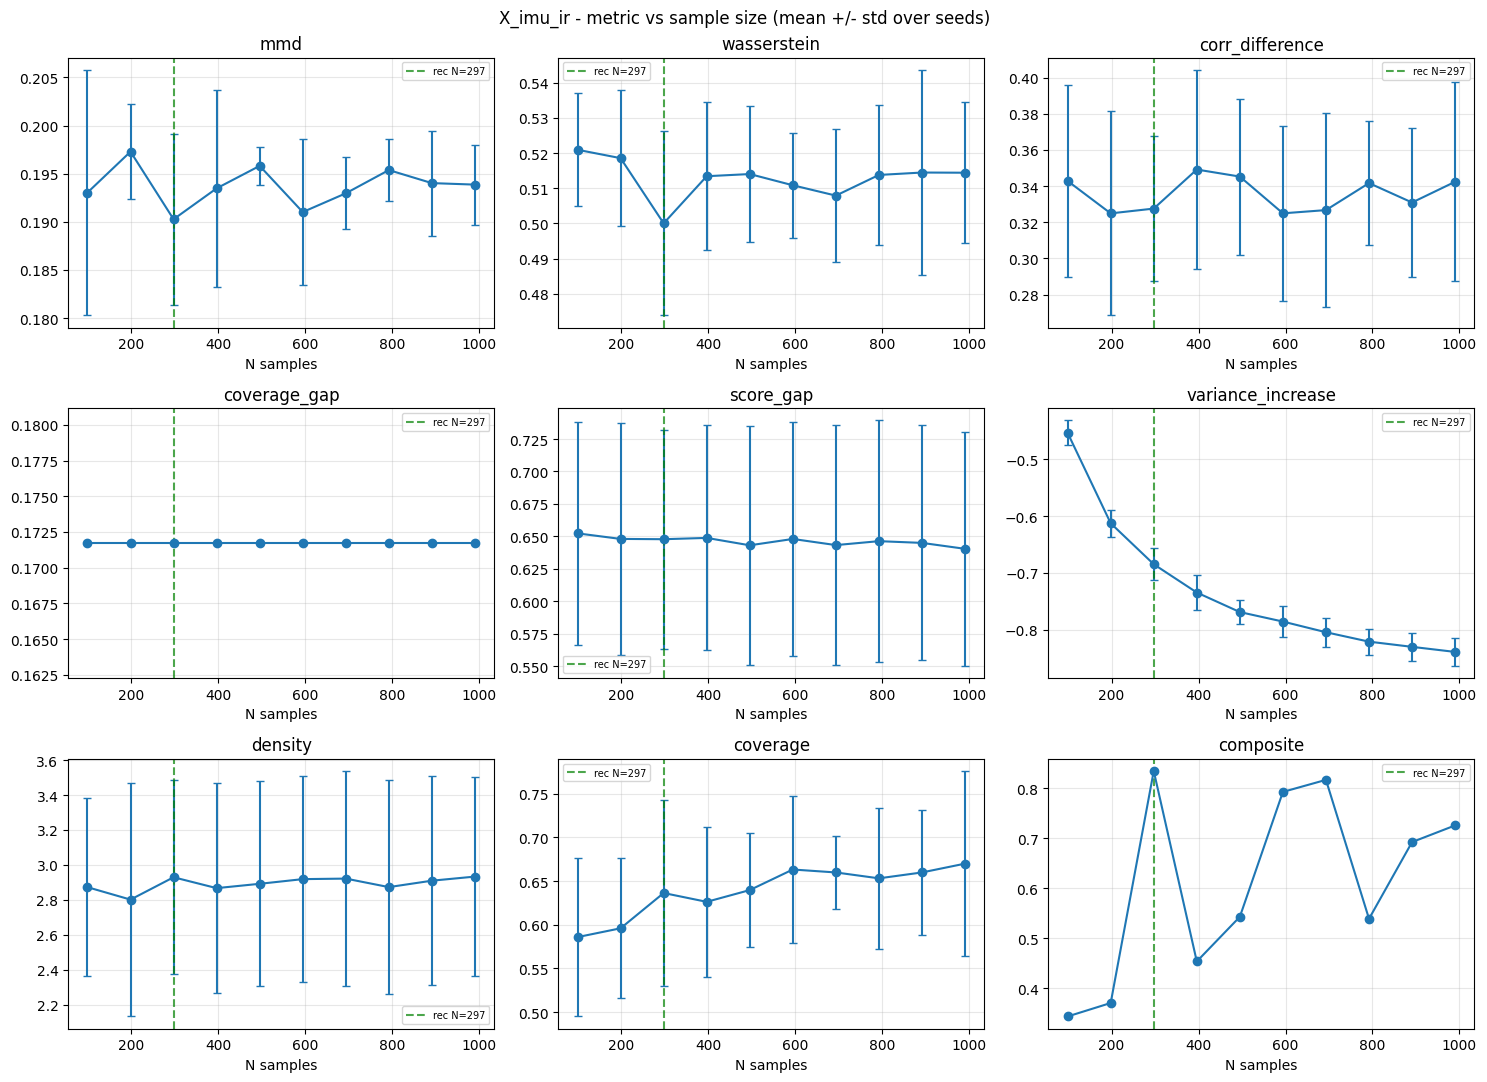

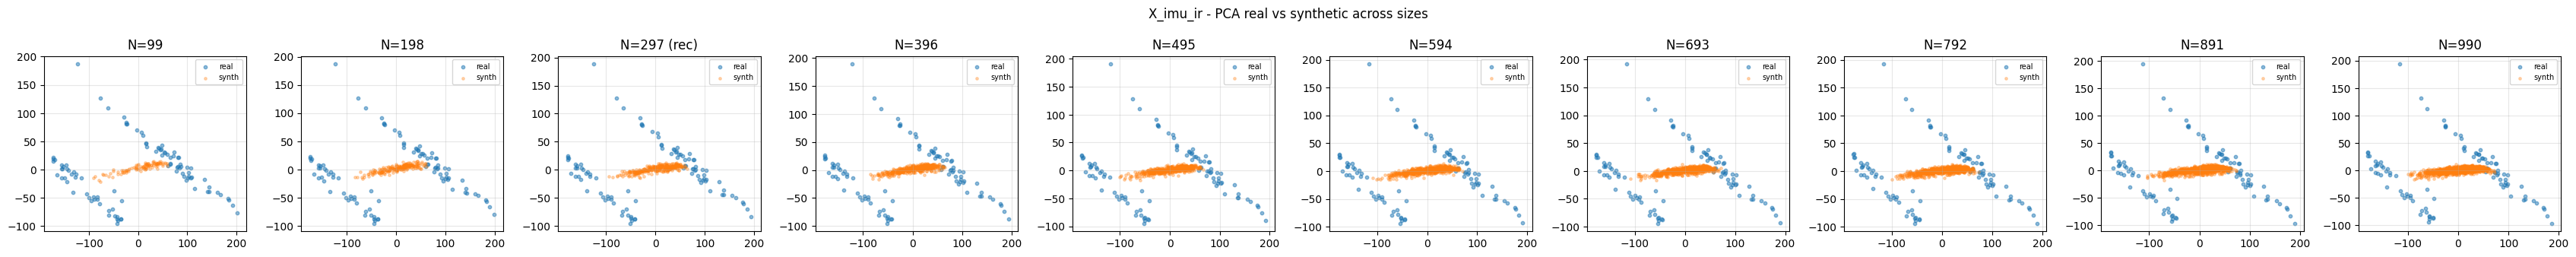

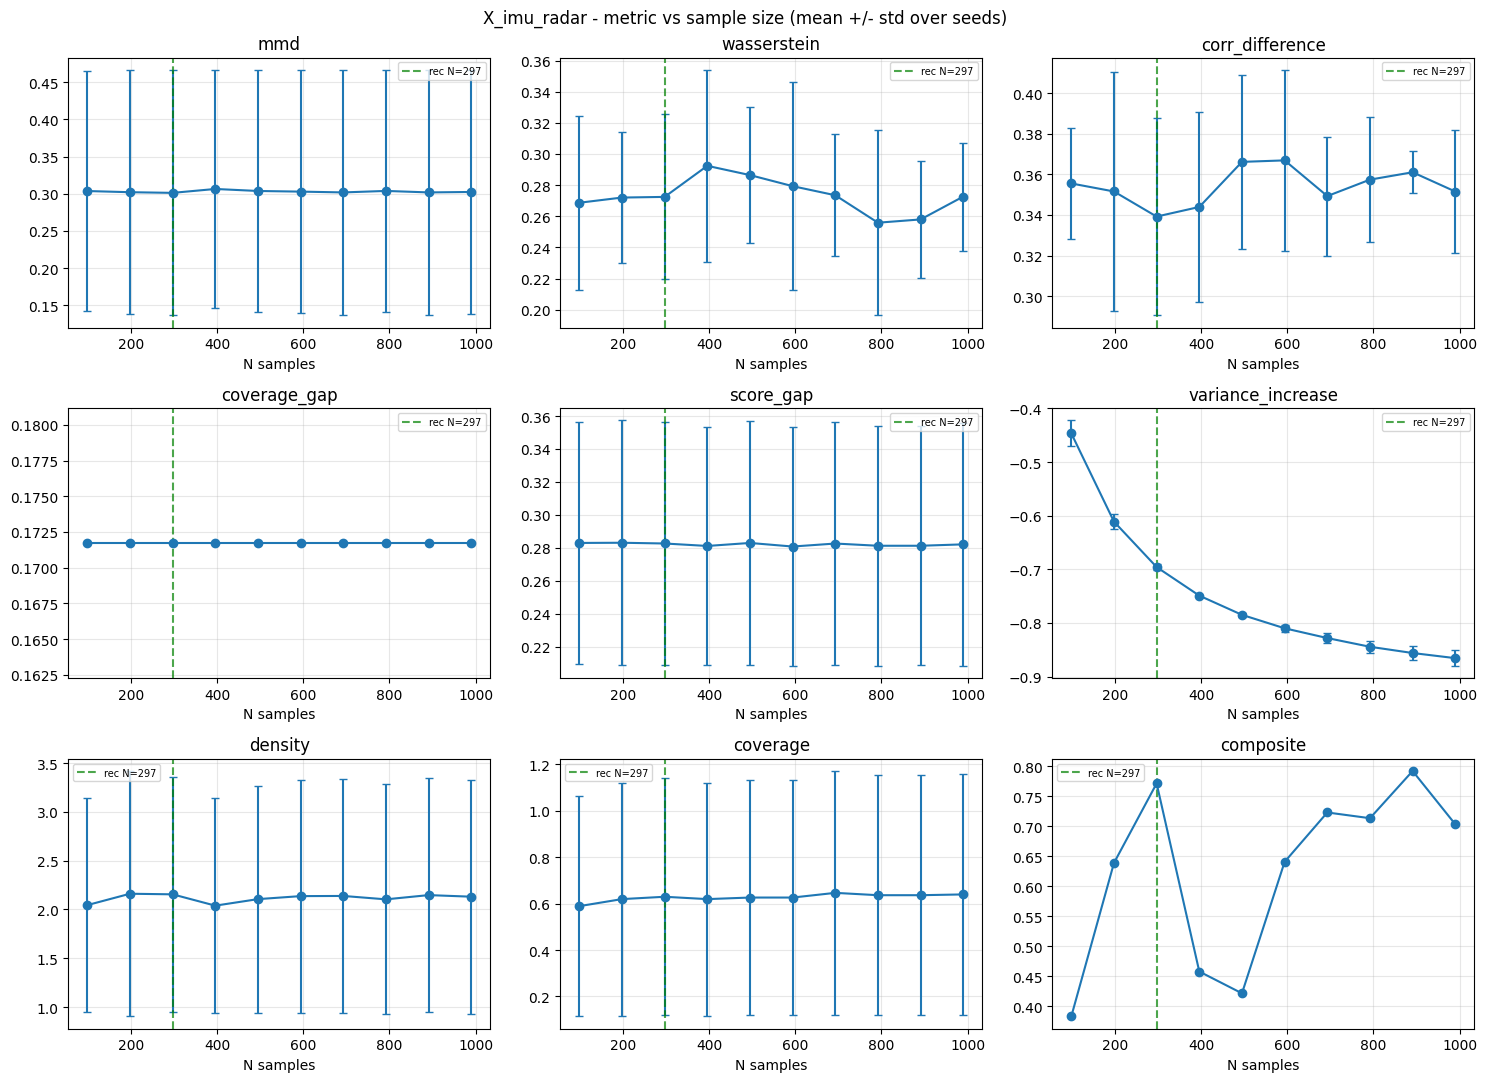

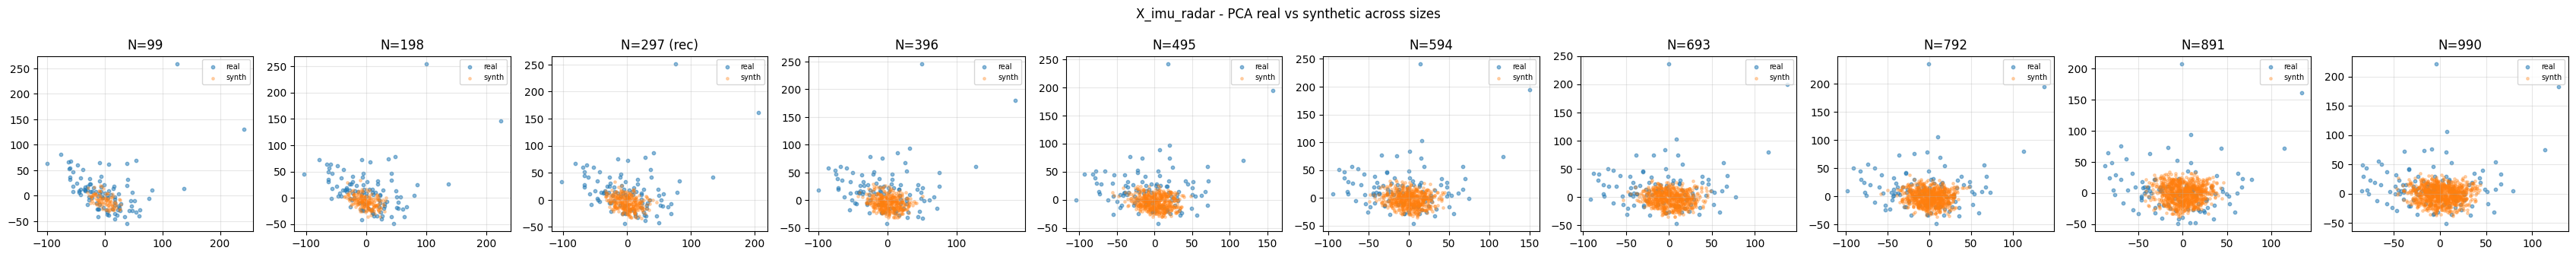

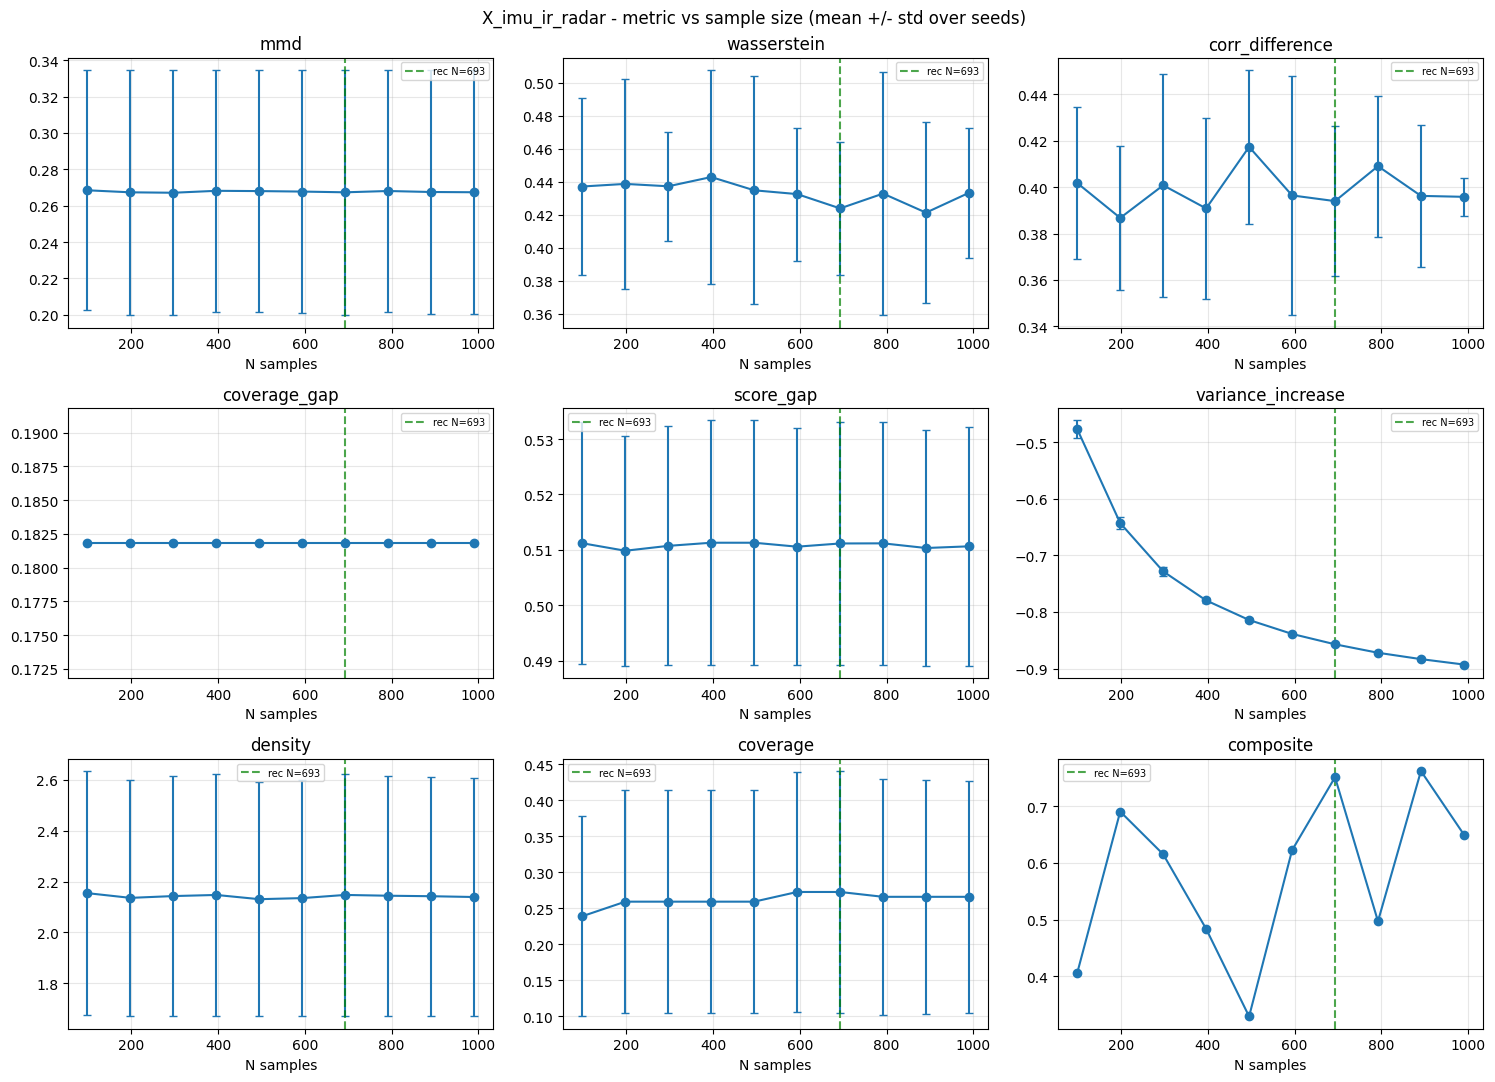

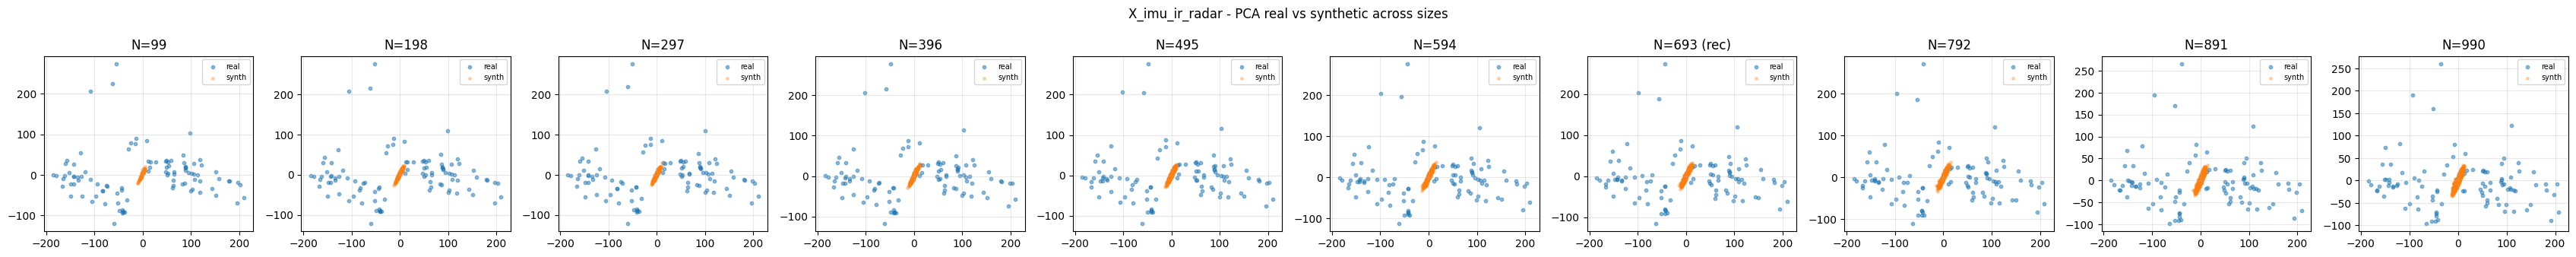

In [43]:
def plot_curves(name):
    sub=AGG[AGG.dataset==name].sort_values("N"); ss=AGG_STD[AGG_STD.dataset==name].sort_values("N")
    mets=["mmd","wasserstein","corr_difference","coverage_gap","score_gap","variance_increase","density","coverage","composite"]
    recN=REC[name]["N"]; fig,axes=plt.subplots(3,3,figsize=(15,11))
    for ax,mt in zip(axes.ravel(),mets):
        x=sub["N"].values; y=sub[mt].values
        yerr=ss[mt].values if mt in ss and mt!="composite" else None
        ax.errorbar(x,y,yerr=yerr,marker="o",capsize=3)
        ax.axvline(recN,color="green",ls="--",alpha=.7,label=f"rec N={recN}")
        ax.set_title(mt); ax.set_xlabel("N samples"); ax.grid(alpha=.3); ax.legend(fontsize=7)
    fig.suptitle(f"{name} - metric vs sample size (mean +/- std over seeds)")
    fig.tight_layout(); fig.savefig(CFG.output_dir/f"{name}_curves.png",dpi=110); plt.show(); plt.close(fig)

def plot_pca(name):
    Re=EMB[name]["Re"]; syn=EMB[name]["synth"]; sizes=sorted(syn)
    fig,axes=plt.subplots(1,len(sizes),figsize=(3.4*len(sizes),3.4),squeeze=False)
    for j,N in enumerate(sizes):
        allp=np.vstack([Re,syn[N]]); p=PCA(2,random_state=CFG.seed).fit_transform(allp)
        axes[0][j].scatter(*p[:len(Re)].T,s=10,alpha=.5,label="real")
        axes[0][j].scatter(*p[len(Re):].T,s=6,alpha=.3,label="synth")
        tag=" (rec)" if N==REC[name]["N"] else ""
        axes[0][j].set_title(f"N={N}{tag}"); axes[0][j].legend(fontsize=7); axes[0][j].grid(alpha=.3)
    fig.suptitle(f"{name} - PCA real vs synthetic across sizes"); fig.tight_layout()
    fig.savefig(CFG.output_dir/f"{name}_pca.png",dpi=110); plt.show(); plt.close(fig)

for name in RAW:
    plot_curves(name); plot_pca(name)


## 13. Save synthetic data at the recommended size + package

In [44]:
import shutil
for name in RAW:
    vae,prep,latent,_=MODELS[name]; recN=REC[name]["N"]
    set_seeds(CFG.seed)
    synth=generate(vae,prep,recN,CFG,latent)
    d=CFG.output_dir/name; d.mkdir(parents=True,exist_ok=True)
    np.save(d/"synthetic_recommended.npy",synth)
    with open(d/"prep.pkl","wb") as f: pickle.dump(prep,f)
    vae.decoder.save(d/"decoder.keras")
    pd.DataFrame([{"dataset":name,"recommended_N":recN,"multiplier":REC[name]["multiplier"],
                   "n_features":prep.F_full,"modeled_dim":prep.K}]).to_csv(d/"metadata.csv",index=False)
    print(f"  {name:16s} saved {synth.shape} at recommended N={recN}")
arch=shutil.make_archive(str(CFG.output_dir),"zip",root_dir=str(CFG.output_dir))
print("\nZipped ->",arch)


  X_imu            saved (297, 32, 3) at recommended N=297
  X_imu_ir         saved (297, 32, 771) at recommended N=297
  X_imu_radar      saved (297, 32, 1137) at recommended N=297
  X_imu_ir_radar   saved (693, 32, 1905) at recommended N=693

Zipped -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_size_study.zip


## Reading the results

For each dataset the recommended N is the smallest size where fidelity (MMD / Wasserstein / correlation)
has flattened **and** diversity (coverage / variance increase) has stopped growing — i.e. more samples add
`< recommend_tol` composite quality. Beyond it you are paying compute for near-duplicates.

Caveats: with ~99 real samples the VAE resamples a learned manifold, so a "recommended size" tells you how
much to draw before returns vanish, not how to exceed the data-scarcity ceiling. The knee is averaged over
`n_seeds` splits; raise `n_seeds` to 5 for a tighter estimate. The real reference here is the full real set
(consistent across sizes); the study measures **relative** saturation, not absolute fidelity.